aplicacion de optimifaciones y funciones de error con pytorch en nuestros labs

librerias

In [1]:
# Manejo de directorios y rutas
import os

# Computación numérica y manejo de matrices
import numpy as np

# Manejo y preprocesamiento de datos
import pandas as pd

# Librerías para graficación
from matplotlib import pyplot

# Mostrar gráficos dentro del cuadernillo
%matplotlib inline
import matplotlib.pyplot as plt


In [2]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())
print("CUDA de PyTorch:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.13.0+cu132
CUDA disponible: True
CUDA de PyTorch: 13.2
GPU: NVIDIA GeForce RTX 5050 Laptop GPU


**pracita con regresion multiples, polinomiales**

empezamos con lab 2 "riego de credito"

cragamos el dt

In [3]:
import pandas as pd

df = pd.read_csv("dataset_6/loan (1).csv")

df.head()

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [4]:
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             20000 non-null  str    
 1   Age                         20000 non-null  int64  
 2   AnnualIncome                20000 non-null  int64  
 3   CreditScore                 20000 non-null  int64  
 4   EmploymentStatus            20000 non-null  str    
 5   EducationLevel              20000 non-null  str    
 6   Experience                  20000 non-null  int64  
 7   LoanAmount                  20000 non-null  int64  
 8   LoanDuration                20000 non-null  int64  
 9   MaritalStatus               20000 non-null  str    
 10  NumberOfDependents          20000 non-null  int64  
 11  HomeOwnershipStatus         20000 non-null  str    
 12  MonthlyDebtPayments         20000 non-null  int64  
 13  CreditCardUtilizationRate   20000 non-null

In [5]:
columnas_texto = df.select_dtypes(include="str").columns

for columna in columnas_texto:
    print("\n" + "=" * 50)
    print(columna)
    print("=" * 50)
    print(df[columna].value_counts())


ApplicationDate
ApplicationDate
2018-01-01    1
2018-01-02    1
2018-01-03    1
2018-01-04    1
2018-01-05    1
             ..
2072-09-29    1
2072-09-30    1
2072-10-01    1
2072-10-02    1
2072-10-03    1
Name: count, Length: 20000, dtype: int64

EmploymentStatus
EmploymentStatus
Employed         17036
Self-Employed     1573
Unemployed        1391
Name: count, dtype: int64

EducationLevel
EducationLevel
Bachelor       6054
High School    5908
Associate      4034
Master         3050
Doctorate       954
Name: count, dtype: int64

MaritalStatus
MaritalStatus
Married     10041
Single       6078
Divorced     2882
Widowed       999
Name: count, dtype: int64

HomeOwnershipStatus
HomeOwnershipStatus
Mortgage    7939
Rent        6087
Own         3938
Other       2036
Name: count, dtype: int64

LoanPurpose
LoanPurpose
Home                  5925
Debt Consolidation    5027
Auto                  4034
Education             3008
Other                 2006
Name: count, dtype: int64


In [6]:
# Crear una copia del dataset original
df_modelo = df.copy()

print("Dataset original:", df.shape)
print("Copia para el modelo:", df_modelo.shape)

Dataset original: (20000, 36)
Copia para el modelo: (20000, 36)


In [7]:
# Eliminar la variable que no utilizaremos
df_modelo = df_modelo.drop(columns=["ApplicationDate"])

In [8]:
print("Copia para el modelo:", df_modelo.shape)

Copia para el modelo: (20000, 35)


In [9]:
# Variables categóricas que vamos a transformar
columnas_categoricas = [
    "EmploymentStatus",
    "EducationLevel",
    "MaritalStatus",
    "HomeOwnershipStatus",
    "LoanPurpose"
    
]

# Convertir variables categóricas a variables numéricas
df_modelo = pd.get_dummies(
    df_modelo,
    columns=columnas_categoricas,
    dtype=int
)

In [10]:
print("Copia para el modelo:", df_modelo.shape)

Copia para el modelo: (20000, 51)


cargar los datos

In [11]:
X = df_modelo.drop("RiskScore", axis=1)
y = df_modelo["RiskScore"]

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

Forma de X: (20000, 50)
Forma de y: (20000,)


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (16000, 50)
X_test: (4000, 50)
y_train: (16000,)
y_test: (4000,)


In [13]:
def featureNormalize(X):

    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [ ]:
# Normalización utilizando nuestra función
X_train_norm, mu, sigma = featureNormalize(X_train)

# Aplicamos los mismos parámetros a test
X_test_norm = (X_test - mu) / sigma

In [15]:
import torch

X_train_t = torch.tensor(X_train_norm.to_numpy(), dtype=torch.float32)
X_test_t = torch.tensor(X_test_norm.to_numpy(), dtype=torch.float32)

y_train_t = torch.tensor(y_train.to_numpy(), dtype=torch.float32)
y_test_t = torch.tensor(y_test.to_numpy(), dtype=torch.float32)

In [41]:
D_in = X_train_t.shape[1]
H = 100
D_out = 1

model = torch.nn.Sequential(
    torch.nn.Linear(D_in, H),
    torch.nn.ReLU(),
    torch.nn.Linear(H, D_out)
).to("cuda")

In [42]:
criterion = torch.nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

epochs = 9500
log_each = 100
l = []
model.train()
for e in range(1, epochs+1):

    # forward
    y_pred = model(X_train_t.cuda())

    # loss
    loss = criterion(
    y_pred,
    y_train_t.reshape(-1, 1).cuda()
)
    l.append(loss.item())

    # ponemos a cero los gradientes
    optimizer.zero_grad()

    # Backprop (calculamos todos los gradientes automáticamente)
    loss.backward()

    # update de los pesos
    optimizer.step()

    if not e % log_each:
        print(f"Epoch {e}/{epochs} Loss {np.mean(l):.5f}")


Epoch 100/9500 Loss 454.07108
Epoch 200/9500 Loss 232.24975
Epoch 300/9500 Loss 157.32298
Epoch 400/9500 Loss 119.51654
Epoch 500/9500 Loss 96.67086
Epoch 600/9500 Loss 81.35116
Epoch 700/9500 Loss 70.35396
Epoch 800/9500 Loss 62.07019
Epoch 900/9500 Loss 55.60257
Epoch 1000/9500 Loss 50.41060
Epoch 1100/9500 Loss 46.14932
Epoch 1200/9500 Loss 42.58803
Epoch 1300/9500 Loss 39.56659
Epoch 1400/9500 Loss 36.97034
Epoch 1500/9500 Loss 34.71498
Epoch 1600/9500 Loss 32.73717
Epoch 1700/9500 Loss 30.98840
Epoch 1800/9500 Loss 29.43085
Epoch 1900/9500 Loss 28.03461
Epoch 2000/9500 Loss 26.77570
Epoch 2100/9500 Loss 25.63470
Epoch 2200/9500 Loss 24.59567
Epoch 2300/9500 Loss 23.64544
Epoch 2400/9500 Loss 22.77301
Epoch 2500/9500 Loss 21.96912
Epoch 2600/9500 Loss 21.22593
Epoch 2700/9500 Loss 20.53678
Epoch 2800/9500 Loss 19.89592
Epoch 2900/9500 Loss 19.29841
Epoch 3000/9500 Loss 18.73997
Epoch 3100/9500 Loss 18.21685
Epoch 3200/9500 Loss 17.72577
Epoch 3300/9500 Loss 17.26386
Epoch 3400/9500

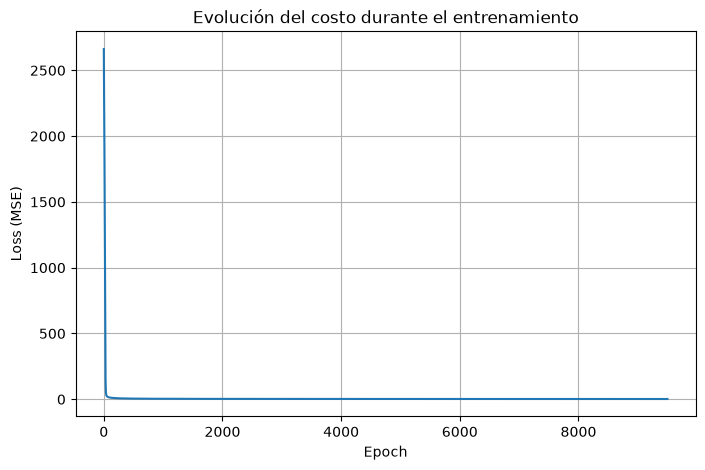

In [43]:
plt.figure(figsize=(8, 5))

plt.plot(l)

plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Evolución del costo durante el entrenamiento")

plt.grid()
plt.show()

In [44]:
def evaluate(x):

    model.eval()

    y_pred = model(x)

    return y_pred

In [45]:
y_pred_test = evaluate(X_test_t.cuda())

In [46]:
for i in range(10):

    print(
        f"Real: {y_test_t[i].item():.2f} "
        f"| Predicción: {y_pred_test[i].item():.2f}"
    )

Real: 41.60 | Predicción: 41.38
Real: 38.40 | Predicción: 39.07
Real: 53.00 | Predicción: 51.97
Real: 50.00 | Predicción: 54.04
Real: 51.00 | Predicción: 52.27
Real: 47.00 | Predicción: 46.98
Real: 52.00 | Predicción: 51.94
Real: 46.00 | Predicción: 45.66
Real: 69.00 | Predicción: 68.88
Real: 55.00 | Predicción: 55.05


empecemos a ver como fucnionaria en una clasificacion binaria con el lab 4 diabetese diagnosed

tratamiento del dataset

In [3]:
df_lab4 = pd.read_csv("dataset_6/diabetes_dataset.csv")

df_lab4.head()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


In [4]:
df_lab4.shape
df_lab4.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  str    
 2   ethnicity                           100000 non-null  str    
 3   education_level                     100000 non-null  str    
 4   income_level                        100000 non-null  str    
 5   employment_status                   100000 non-null  str    
 6   smoking_status                      100000 non-null  str    
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_day           10

In [5]:
# Crear una copia del dataset original
datos_modelo_lab4 = df_lab4.copy()

print("Dataset original:", df_lab4.shape)
print("Copia para el modelo:", datos_modelo_lab4.shape)

Dataset original: (100000, 31)
Copia para el modelo: (100000, 31)


In [6]:
# Eliminar la variable que no utilizaremos
datos_modelo_lab4 = datos_modelo_lab4.drop(columns=["diabetes_stage",])

In [7]:
print("Copia para el modelo:", datos_modelo_lab4.shape)

Copia para el modelo: (100000, 30)


aplicamos one hot encoding

In [8]:
# Variables categóricas que vamos a transformar
columnas_categoricas = [
    "gender",
    "ethnicity",
    "education_level",
    "income_level",
    "employment_status",
    "smoking_status",
]

# Convertir variables categóricas a variables numéricas
datos_modelo_lab4 = pd.get_dummies(
    datos_modelo_lab4,
    columns=columnas_categoricas,
    dtype=int
)

In [9]:
print("Copia para el modelo:", datos_modelo_lab4.shape)

Copia para el modelo: (100000, 48)


In [10]:
datos_modelo_lab4.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 48 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   alcohol_consumption_per_week        100000 non-null  int64  
 2   physical_activity_minutes_per_week  100000 non-null  int64  
 3   diet_score                          100000 non-null  float64
 4   sleep_hours_per_day                 100000 non-null  float64
 5   screen_time_hours_per_day           100000 non-null  float64
 6   family_history_diabetes             100000 non-null  int64  
 7   hypertension_history                100000 non-null  int64  
 8   cardiovascular_history              100000 non-null  int64  
 9   bmi                                 100000 non-null  float64
 10  waist_to_hip_ratio                  100000 non-null  float64
 11  systolic_bp                         10

cargamos las variables 

In [11]:
X_lab4 = datos_modelo_lab4.drop(columns=["diagnosed_diabetes"])
y_lab4 = datos_modelo_lab4["diagnosed_diabetes"]

print("Forma de X:", X_lab4.shape)
print("Forma de y:", y_lab4.shape)

print("\nDistribución de clases:")
print(y_lab4.value_counts())

Forma de X: (100000, 47)
Forma de y: (100000,)

Distribución de clases:
diagnosed_diabetes
1    59998
0    40002
Name: count, dtype: int64


80% train 20%test

In [12]:
from sklearn.model_selection import train_test_split

X_train_lab4, X_test_lab4, y_train_lab4, y_test_lab4 = train_test_split(
    X_lab4,
    y_lab4,
    test_size=0.20,
    random_state=42,
    stratify=y_lab4
)

print("X_train:", X_train_lab4.shape)
print("X_test:", X_test_lab4.shape)
print("y_train:", y_train_lab4.shape)
print("y_test:", y_test_lab4.shape)

X_train: (80000, 47)
X_test: (20000, 47)
y_train: (80000,)
y_test: (20000,)


In [15]:
print("Distribución original:")
print(y_lab4.value_counts())
print(y_lab4.value_counts(normalize=True))

print("\nDistribución en TRAIN:")
print(y_train_lab4.value_counts())
print(y_train_lab4.value_counts(normalize=True))

print("\nDistribución en TEST:")
print(y_test_lab4.value_counts())
print(y_test_lab4.value_counts(normalize=True))

Distribución original:
diagnosed_diabetes
1    59998
0    40002
Name: count, dtype: int64
diagnosed_diabetes
1    0.59998
0    0.40002
Name: proportion, dtype: float64

Distribución en TRAIN:
diagnosed_diabetes
1    47998
0    32002
Name: count, dtype: int64
diagnosed_diabetes
1    0.599975
0    0.400025
Name: proportion, dtype: float64

Distribución en TEST:
diagnosed_diabetes
1    12000
0     8000
Name: count, dtype: int64
diagnosed_diabetes
1    0.6
0    0.4
Name: proportion, dtype: float64


metodo SMOTE

In [16]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy=0.95, random_state=42)

X_train_lab4, y_train_lab4 = smote.fit_resample(
    X_train_lab4,
    y_train_lab4
)

print("Después de SMOTE:")
print("X_train:", X_train_lab4.shape)
print("y_train:", y_train_lab4.shape)

print("\nDistribución de clases:")
print(y_train_lab4.value_counts())

Después de SMOTE:
X_train: (93596, 47)
y_train: (93596,)

Distribución de clases:
diagnosed_diabetes
1    47998
0    45598
Name: count, dtype: int64


In [17]:
print("\nDistribución en TRAIN:")
print(y_train_lab4.value_counts())
print(y_train_lab4.value_counts(normalize=True))


Distribución en TRAIN:
diagnosed_diabetes
1    47998
0    45598
Name: count, dtype: int64
diagnosed_diabetes
1    0.512821
0    0.487179
Name: proportion, dtype: float64


normalizacion

In [18]:
def featureNormalize(X):

    X_norm = X.copy()

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)

    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [19]:
X_train_lab4_norm, mu_lab4, sigma_lab4 = featureNormalize(X_train_lab4)

X_test_lab4_norm = (X_test_lab4 - mu_lab4) / sigma_lab4

convertir a tensor y mandar a nucleo cuda

In [20]:
import torch

X_train_lab4_t = torch.tensor(
    X_train_lab4_norm.to_numpy(),
    dtype=torch.float32
).cuda()

X_test_lab4_t = torch.tensor(
    X_test_lab4_norm.to_numpy(),
    dtype=torch.float32
).cuda()

y_train_lab4_t = torch.tensor(
    y_train_lab4.to_numpy(),
    dtype=torch.float32
).cuda()

y_test_lab4_t = torch.tensor(
    y_test_lab4.to_numpy(),
    dtype=torch.float32
).cuda()

realizamos el modelo secuencial

In [21]:
D_in = X_train_lab4_t.shape[1]
H = 100
D_out = 1

model = torch.nn.Sequential(
    torch.nn.Linear(D_in, H),
    torch.nn.ReLU(),
    torch.nn.Linear(H, D_out)
).to("cuda")

optimizaciones y funcion de perdida para binary corss entropy, usando una funcion que ya incluye sigmoID

In [22]:
criterion = torch.nn.BCEWithLogitsLoss()

In [43]:
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.08
)

entrenamiento

In [46]:
epochs = 12000
log_each = 100

l_lab4 = []

model.train()

for e in range(1, epochs + 1):

    # Forward
    logits_lab4 = model(X_train_lab4_t)

    # Loss
    loss_lab4 = criterion(
        logits_lab4,
        y_train_lab4_t.reshape(-1, 1)
    )

    l_lab4.append(loss_lab4.item())

    # Reiniciar gradientes
    optimizer.zero_grad()

    # Backpropagation
    loss_lab4.backward()

    # Actualizar pesos
    optimizer.step()

    if not e % log_each:
        print(
            f"Epoch {e}/{epochs} "
            f"Loss {loss_lab4.item():.5f}"
        )

Epoch 100/12000 Loss 0.16179
Epoch 200/12000 Loss 0.16174
Epoch 300/12000 Loss 0.16170
Epoch 400/12000 Loss 0.16165
Epoch 500/12000 Loss 0.16161
Epoch 600/12000 Loss 0.16156
Epoch 700/12000 Loss 0.16152
Epoch 800/12000 Loss 0.16147
Epoch 900/12000 Loss 0.16143
Epoch 1000/12000 Loss 0.16138
Epoch 1100/12000 Loss 0.16134
Epoch 1200/12000 Loss 0.16129
Epoch 1300/12000 Loss 0.16125
Epoch 1400/12000 Loss 0.16120
Epoch 1500/12000 Loss 0.16116
Epoch 1600/12000 Loss 0.16111
Epoch 1700/12000 Loss 0.16107
Epoch 1800/12000 Loss 0.16103
Epoch 1900/12000 Loss 0.16098
Epoch 2000/12000 Loss 0.16094
Epoch 2100/12000 Loss 0.16090
Epoch 2200/12000 Loss 0.16085
Epoch 2300/12000 Loss 0.16081
Epoch 2400/12000 Loss 0.16077
Epoch 2500/12000 Loss 0.16073
Epoch 2600/12000 Loss 0.16068
Epoch 2700/12000 Loss 0.16064
Epoch 2800/12000 Loss 0.16060
Epoch 2900/12000 Loss 0.16055
Epoch 3000/12000 Loss 0.16051
Epoch 3100/12000 Loss 0.16047
Epoch 3200/12000 Loss 0.16043
Epoch 3300/12000 Loss 0.16038
Epoch 3400/12000 Lo

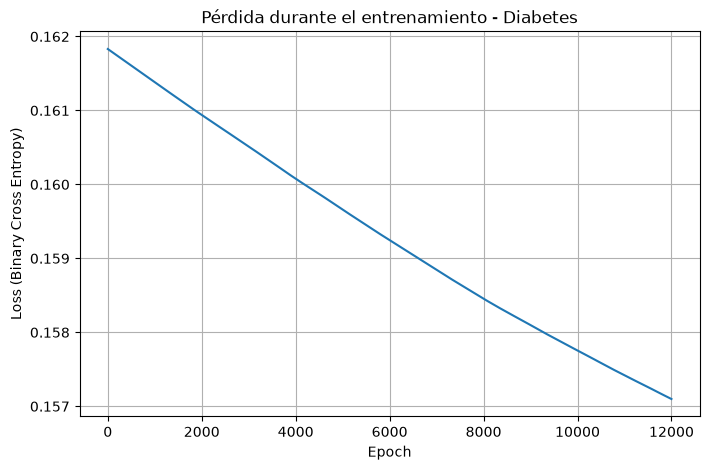

In [47]:
plt.figure(figsize=(8, 5))

plt.plot(l_lab4)

plt.xlabel("Epoch")
plt.ylabel("Loss (Binary Cross Entropy)")
plt.title("Pérdida durante el entrenamiento - Diabetes")
plt.grid()

plt.show()

In [49]:
from sklearn.metrics import accuracy_score

def evaluate_lab4(x):

    model.eval()

    # Forward
    logits = model(x)

    # Convertimos logits en probabilidades
    probabilidades = torch.sigmoid(logits)

    # Aplicamos umbral 0.5
    predicciones = (probabilidades >= 0.5).float()

    return predicciones

In [52]:
y_pred_lab4 = evaluate_lab4(X_test_lab4_t)

accuracy_lab4 = (
    (y_pred_lab4 == y_test_lab4_t.reshape(-1, 1))
    .float()
    .mean()
)

print(f"Accuracy: {accuracy_lab4.item() * 100:.2f}%")

Accuracy: 90.85%


ahora aplicamos en lab5

cargamos el datset

In [1]:
import random

In [5]:
df_emnist = pd.read_csv(
    "dataset_6/emnist-balanced-train.csv",
    header=None
)

print("Forma del dataset:", df_emnist.shape)

Forma del dataset: (112800, 785)


In [6]:
datos_modelo_emnist = df_emnist.copy()

print("Dataset original:", df_emnist.shape)
print("Copia para el modelo:", datos_modelo_emnist.shape)

Dataset original: (112800, 785)
Copia para el modelo: (112800, 785)


In [7]:
X_emnist = datos_modelo_emnist.iloc[:, 1:]
y_emnist = datos_modelo_emnist.iloc[:, 0]

print("Forma de X:", X_emnist.shape)
print("Forma de y:", y_emnist.shape)

Forma de X: (112800, 784)
Forma de y: (112800,)


In [8]:
X_emnist = X_emnist.to_numpy()
y_emnist = y_emnist.to_numpy()

In [9]:
from sklearn.model_selection import train_test_split

X_train_emnist, X_test_emnist, y_train_emnist, y_test_emnist = train_test_split(
    X_emnist,
    y_emnist,
    test_size=0.20,
    random_state=42,
    stratify=y_emnist
)

print("X_train:", X_train_emnist.shape)
print("y_train:", y_train_emnist.shape)
print("X_test:", X_test_emnist.shape)
print("y_test:", y_test_emnist.shape)

X_train: (90240, 784)
y_train: (90240,)
X_test: (22560, 784)
y_test: (22560,)


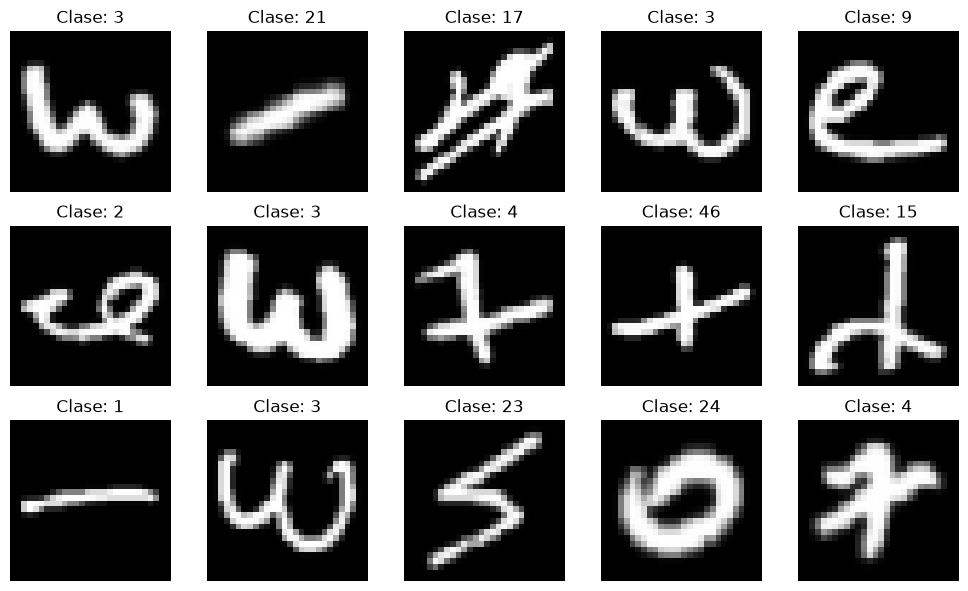

In [10]:
r, c = 3, 5

fig = plt.figure(figsize=(2*c, 2*r))

for _r in range(r):
    for _c in range(c):

        plt.subplot(r, c, _r*c + _c + 1)

        ix = random.randint(0, len(X_train_emnist) - 1)

        img = X_train_emnist[ix]

        plt.imshow(
            img.reshape(28, 28),
            cmap="gray"
        )

        plt.axis("off")
        plt.title(f"Clase: {y_train_emnist[ix]}")

plt.tight_layout()
plt.show()

In [11]:
# Normalizamos los píxeles
X_train_emnist = X_train_emnist / 255.0
X_test_emnist = X_test_emnist / 255.0

# Convertimos las etiquetas a enteros
y_train_emnist = y_train_emnist.astype(np.int64)
y_test_emnist = y_test_emnist.astype(np.int64)

de tensor a cuda

In [12]:
import torch

X_train_emnist_t = torch.tensor(
    X_train_emnist,
    dtype=torch.float32
).cuda()

X_test_emnist_t = torch.tensor(
    X_test_emnist,
    dtype=torch.float32
).cuda()

y_train_emnist_t = torch.tensor(
    y_train_emnist,
    dtype=torch.long
).cuda()

y_test_emnist_t = torch.tensor(
    y_test_emnist,
    dtype=torch.long
).cuda()

creamos el modelo secuencyal 

In [110]:
D_in, H1, H2, D_out = 784, 250, 100, 47
model_emnist = torch.nn.Sequential(
torch.nn.Linear(D_in, H1),
torch.nn.ReLU(),
torch.nn.Linear(H1, H2),
torch.nn.ReLU(),
torch.nn.Linear(H2, D_out),
).cuda()

In [111]:
outputs = model_emnist(
    torch.randn(600, 784).cuda()
)

outputs.shape

torch.Size([600, 47])

In [115]:
criterion_emnist = torch.nn.CrossEntropyLoss()

optimizer_emnist = torch.optim.SGD(
    model_emnist.parameters(),
    lr=0.8
)

epochs = 1500
log_each = 10

l_emnist = []

model_emnist.train()

for e in range(1, epochs + 1):

    # Forward
    y_pred_emnist = model_emnist(X_train_emnist_t)

    # Loss
    loss_emnist = criterion_emnist(
        y_pred_emnist,
        y_train_emnist_t
    )

    l_emnist.append(loss_emnist.item())

    # Ponemos a cero los gradientes
    optimizer_emnist.zero_grad()

    # Backpropagation
    loss_emnist.backward()

    # Actualizamos los pesos
    optimizer_emnist.step()

    if not e % log_each:
        print(
            f"Epoch {e}/{epochs} "
            f"Loss {np.mean(l_emnist):.5f}"
        )

Epoch 10/1500 Loss 5.07715
Epoch 20/1500 Loss 3.39093
Epoch 30/1500 Loss 2.62592
Epoch 40/1500 Loss 2.15515
Epoch 50/1500 Loss 1.85296
Epoch 60/1500 Loss 1.65159
Epoch 70/1500 Loss 1.49679
Epoch 80/1500 Loss 1.37772
Epoch 90/1500 Loss 1.28049
Epoch 100/1500 Loss 1.20148
Epoch 110/1500 Loss 1.13727
Epoch 120/1500 Loss 1.08191
Epoch 130/1500 Loss 1.03422
Epoch 140/1500 Loss 0.99258
Epoch 150/1500 Loss 0.95654
Epoch 160/1500 Loss 0.92578
Epoch 170/1500 Loss 0.89684
Epoch 180/1500 Loss 0.87109
Epoch 190/1500 Loss 0.84759
Epoch 200/1500 Loss 0.82732
Epoch 210/1500 Loss 0.80736
Epoch 220/1500 Loss 0.78910
Epoch 230/1500 Loss 0.77214
Epoch 240/1500 Loss 0.75652
Epoch 250/1500 Loss 0.74284
Epoch 260/1500 Loss 0.72944
Epoch 270/1500 Loss 0.71656
Epoch 280/1500 Loss 0.70531
Epoch 290/1500 Loss 0.69525
Epoch 300/1500 Loss 0.68471
Epoch 310/1500 Loss 0.67518
Epoch 320/1500 Loss 0.66755
Epoch 330/1500 Loss 0.65842
Epoch 340/1500 Loss 0.64997
Epoch 350/1500 Loss 0.64185
Epoch 360/1500 Loss 0.63465
E

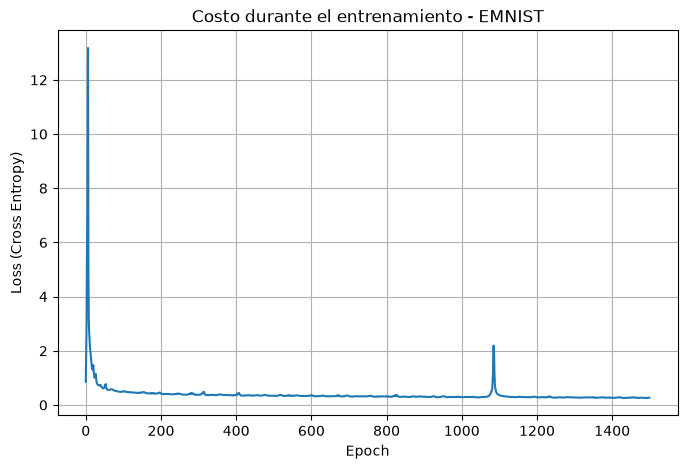

In [116]:
plt.figure(figsize=(8, 5))

plt.plot(l_emnist)

plt.xlabel("Epoch")
plt.ylabel("Loss (Cross Entropy)")
plt.title("Costo durante el entrenamiento - EMNIST")

plt.grid()
plt.show()

In [117]:
from sklearn.metrics import accuracy_score

def evaluate_emnist(x):

    model_emnist.eval()

    # Forward
    logits = model_emnist(x)

    # Convertimos logits a probabilidades
    probabilidades = torch.softmax(logits, dim=1)

    # Elegimos la clase con mayor probabilidad
    predicciones = torch.argmax(
        probabilidades,
        dim=1
    )

    return predicciones

In [118]:
y_pred_emnist = evaluate_emnist(
    X_test_emnist_t
)

accuracy_emnist = accuracy_score(
    y_test_emnist_t.cpu().numpy(),
    y_pred_emnist.cpu().numpy()
)

print(f"Accuracy: {accuracy_emnist * 100:.2f}%")

Accuracy: 83.05%


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_10188\193575723.py:17: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:255.)
  torch.tensor(


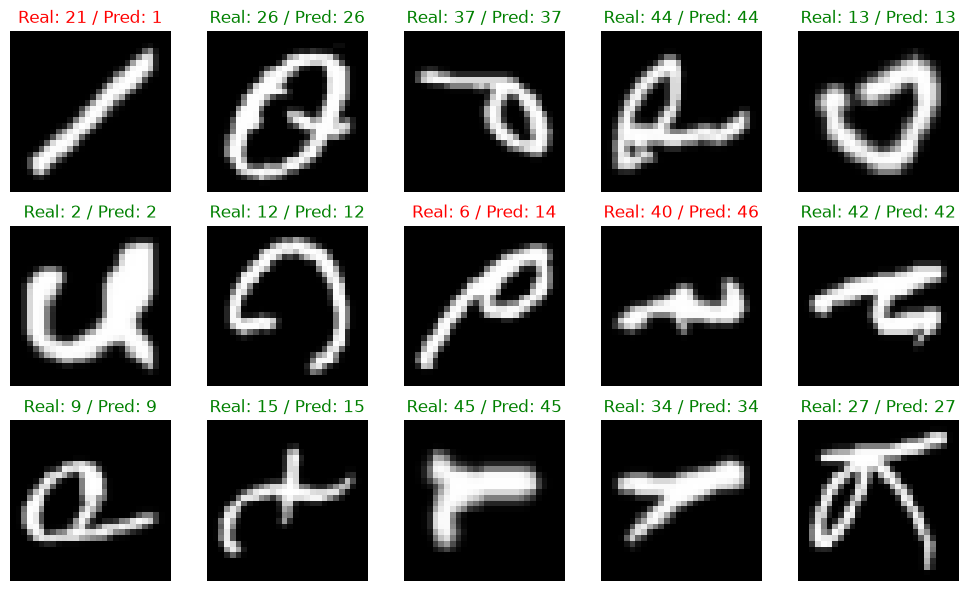

In [119]:
r, c = 3, 5

fig = plt.figure(figsize=(2*c, 2*r))

for _r in range(r):
    for _c in range(c):

        plt.subplot(r, c, _r*c + _c + 1)

        ix = random.randint(0, len(X_test_emnist) - 1)

        img = X_test_emnist[ix]

        y_real = y_test_emnist[ix]

        y_pred = evaluate_emnist(
            torch.tensor(
                [img],
                dtype=torch.float32,
                device="cuda"
            )
        )[0].item()

        plt.imshow(
            img.reshape(28, 28),
            cmap="gray"
        )

        plt.axis("off")

        plt.title(
            f"Real: {y_real} / Pred: {y_pred}",
            color="green" if y_real == y_pred else "red"
        )

plt.tight_layout()
plt.show()